# Convolutional Neural Networks: Application (1)

In this notebook, you will:
- Create a **Mood Classifer (Binary)** using the TF Keras Sequential API

**After this assignment we will be able to:**
- Build and train a ConvNet in TensorFlow for a __binary__ classification problem

# Load Library

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.layers as tfl

# Mood Classifier (Binary)

We'll be using the **Happy House dataset**, which contains images of peoples' faces. Our task will be to build a ConvNet that **determines whether the people in the images are smiling or not** -- because they only get to enter the house if they're smiling!

## 1. Load Data and Split into Train/Test Sets

### 1.1 - Load Data from .h5 File

In [2]:
# ======= DATASETS STRUCTURE =======
train_dataset = h5py.File("datasets/train_happy.h5", "r")
test_dataset = h5py.File("datasets/test_happy.h5", "r")

def print_structure_clean(dataset, title):
    print(f"\n{title}")
    for key in dataset.keys():
        print(f"  • {key}")

print_structure_clean(train_dataset, "Train Set Structure")
print_structure_clean(test_dataset, "Test Set Structure")


Train Set Structure
  • list_classes
  • train_set_x
  • train_set_y

Test Set Structure
  • list_classes
  • test_set_x
  • test_set_y


In [3]:
# ======= TRAINING SET =======
train_set_x_orig = np.array(train_dataset["train_set_x"][:])
train_set_y_orig = np.array(train_dataset["train_set_y"][:])
print("train_set_x_orig shape:", train_set_x_orig.shape)
print("train_set_y_orig shape:", train_set_y_orig.shape)

train_set_x_orig shape: (600, 64, 64, 3)
train_set_y_orig shape: (600,)


In [4]:
# ======= TEST SET =======
test_set_x_orig = np.array(test_dataset["test_set_x"][:])
test_set_y_orig = np.array(test_dataset["test_set_y"][:])
print("test_set_x_orig shape:", test_set_x_orig.shape)
print("test_set_y_orig shape:", test_set_y_orig.shape)

test_set_x_orig shape: (150, 64, 64, 3)
test_set_y_orig shape: (150,)


In [5]:
# ======= CLASSES =======
list_classes = np.array(train_dataset["list_classes"][:])
print("Classes shape:", list_classes.shape)

Classes shape: (2,)


**_Note_**: We can see that:
- **X - feature**: is in **correct** format of `(batch_size, height, weight, channels)`
- **Y - label** is in **incorrect** format. We need `(1, #classes)` - a 2D format, not in 1D vector

⇒ We need to convert Y - label to correct format

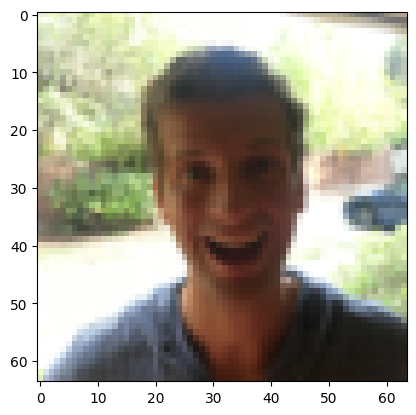

In [6]:
# Example of an image from the dataset
index = 125
plt.imshow(train_set_x_orig[index]) #display sample training image
plt.show()

### 1.2 - Convert all 1D -> 2D Array

We need to do that because it helps:
- **Easier for compute Loss**
- **Match with Output model**

**_Note:_** We do **NOT need** to **convert classes** because it does **NOT participate** in the **calculation** nor **input** for the **model**.

In [7]:
train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
print("train_set_y_orig shape:", train_set_y_orig.shape)
print("test_set_y_orig shape:", test_set_y_orig.shape)

train_set_y_orig shape: (1, 600)
test_set_y_orig shape: (1, 150)


### 1.3 - Split Data

Images are **64x64** pixels in RGB format (3 channels):
- **X_train/X_test shape**: `(batch_size, height, width, channels)`
- **Y_train/Y_test shape**: `(batch_size, 1)`
- **Classes shape**: `(#classes,)`

In [8]:
# Normalize image vectors
X_train = train_set_x_orig/255.
X_test = test_set_x_orig/255.

# Reshape
Y_train = train_set_y_orig.T
Y_test = test_set_y_orig.T

# Classes
classes = list_classes

print ("Number of training examples = " + str(X_train.shape[0]))
print ("Number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))
print ("Classes shape: " + str(classes.shape))

Number of training examples = 600
Number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600, 1)
X_test shape: (150, 64, 64, 3)
Y_test shape: (150, 1)
Classes shape: (2,)


## 2. The Sequential API

<font color="purple">

**_Definition_**:
- **Sequential API:** Model is a **sequence (linear series)** of layers arranged in order: `Input → Layer 1 → Layer 2 → ... → Output`
- Each layer has **exactly one input** tensor and **one output** tensor.

</font>

### 2.1 - Create the Sequential Model Pipeline

Implement the `happyModel` function below to build the following model:

<img src="images/Happy_Model.png">

Take help from [tf.keras.layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers)

Also, plug in the following parameters for all the steps:

 - [ZeroPadding2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/ZeroPadding2D): padding 3, input shape 64 x 64 x 3
 - [Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D): Use 32 7x7 filters, stride 1
 - [BatchNormalization](https://www.tensorflow.org/api_docs/python/tf/keras/layers/BatchNormalization): for axis 3
 - [ReLU](https://www.tensorflow.org/api_docs/python/tf/keras/layers/ReLU)
 - [MaxPool2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D): Using default parameters
 - [Flatten](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten) the previous output.
 - Fully-connected ([Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)) layer: Apply a fully connected layer with 1 neuron and a sigmoid activation.

In [9]:
def happyModel():
    """
    Implements the forward propagation for the binary classification

    Arguments:
    None

    Returns:
    model -- TF Keras model (object containing the information for the entire training process)
    """
    model = tf.keras.Sequential([
        # 1. ZeroPad
        tfl.ZeroPadding2D(padding=(3, 3), input_shape=(64, 64, 3)),

        # 2. Conv
        tfl.Conv2D(32, 7, strides=(1,1)),

        # 3. BatchNorm
        tfl.BatchNormalization(axis=3),

        # 4. ReLU
        tfl.ReLU(),

        # 5. MaxPool
        tfl.MaxPool2D(),

        #6. Flatten
        tfl.Flatten(),

        # 7. Dense
        tfl.Dense(1, activation='sigmoid')
    ])

    return model

In [10]:
happy_model = happyModel()
happy_model.summary()

C:\Users\PC\miniconda3\envs\Classical-Model\lib\site-packages\keras\src\layers\reshaping\zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ zero_padding2d (ZeroPadding2D)  │ (None, 70, 70, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 64 (256.00 B)

### 2.2 - Set up before Training

Before Training, we need to define:
- How to **Calculate Error**
- How to **Update Weight**
- How to **Measure Performance**

In [11]:
happy_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

### 2.3 - Train Model

In [12]:
happy_model.fit(X_train, Y_train, epochs=10, batch_size=16)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6933 - loss: 1.1209
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8983 - loss: 0.2748
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9267 - loss: 0.1818
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9717 - loss: 0.0954
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9633 - loss: 0.1148
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9550 - loss: 0.1190
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9567 - loss: 0.1182
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9533 - loss: 0.1250
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9750 - loss: 0.0870
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9850 - loss: 0.0529


### 2.4 - Evaluate Model

In [13]:
happy_model.evaluate(X_test, Y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9267 - loss: 0.1979


[0.19794227182865143, 0.9266666769981384]